In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

In [2]:
%cd ..

/common/wut4/workspace/OCT


In [3]:
feature_gf = np.load('./grafted/225/grafted_features.npy')
df_gf = pd.read_csv('./grafted/225/grafted_result_225.csv')
feature_test = np.load('./test_features.npy')
df_test = pd.read_csv('./test_df.csv')

In [4]:
print(np.shape(feature_gf), np.shape(feature_test))

(11900, 512) (14399, 512)


In [5]:
df_gf = df_gf[['path']]
df_gf['side'] = df_gf['path'].apply(lambda x: x.split('/')[5].split('_')[1])
df_gf['gt'] = df_gf['path'].apply(lambda x: x.split('/')[4].split(' ')[-1])
df_gf['id'] = df_gf['path'].apply(lambda x: x.split('/')[5].split('_')[0])
df_gf['type'] = 'graft'

In [6]:
df_test['side'] = df_test['case'].apply(lambda x: x.split('_')[1])
df_test['gt'] = df_test['date'].apply(lambda x: x.split('_')[0])
df_test = df_test[['path', 'side', 'gt', 'id']]
df_test['type'] = 'test'

In [7]:
feature = np.vstack((feature_gf, feature_test))

In [8]:
df = pd.concat([df_gf, df_test], axis=0)

In [9]:
df.head()

,path,side,gt,id,type
0,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,OD,P60,G401,graft
1,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,OD,P60,G401,graft
2,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,OD,P60,G401,graft
3,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,OD,P60,G401,graft
4,./data/OCT-Tiff/Grafted eyes/400K P60/G401_OD_...,OD,P60,G401,graft


In [10]:
np.save('feature.npy', feature)
df.to_csv('total.csv', index=False)

In [10]:
pca = PCA(n_components=2)
output_pca = pca.fit_transform(feature)

In [11]:
np.shape(output_pca)

(26299, 2)

In [12]:
custom_palette = {'P20': 'red', 'P40': 'blue', 'P60': 'green', 'P90': 'purple', 'P120': 'orange'}

<Axes: >

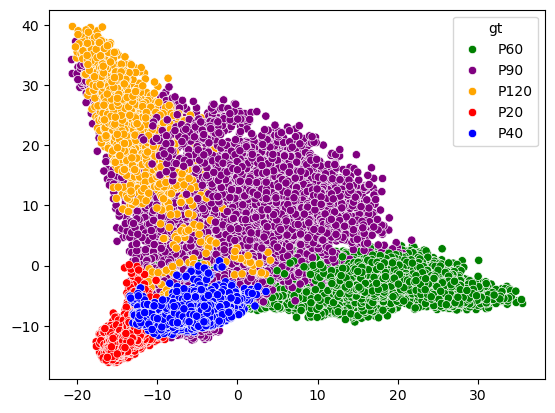

In [13]:
sns.scatterplot(x=output_pca[:, 0], y=output_pca[:, 1], hue=df.loc[:, 'gt'], palette=custom_palette)

<Axes: >

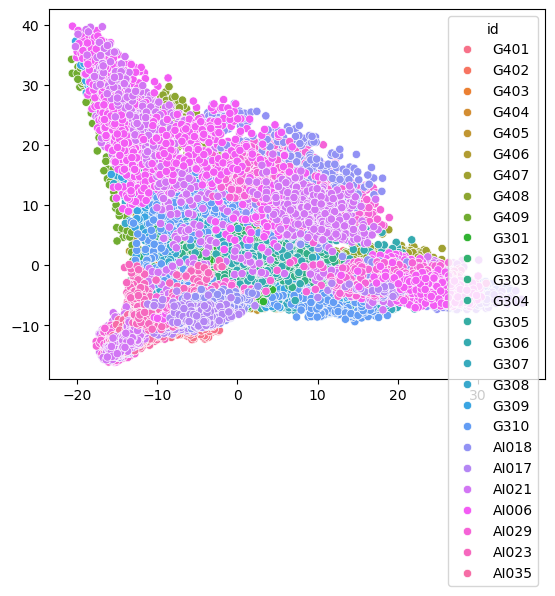

In [14]:
sns.scatterplot(x=output_pca[:, 0], y=output_pca[:, 1], hue=df.loc[:, 'id'])

<Axes: >

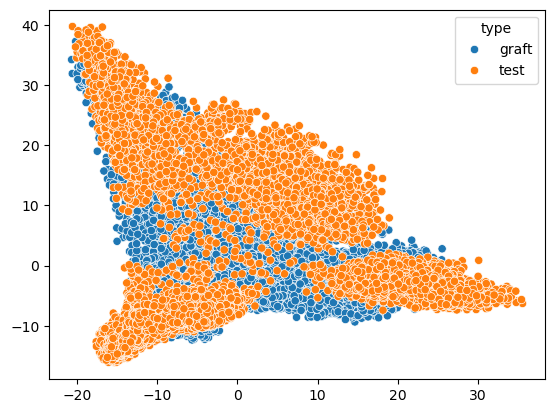

In [15]:
sns.scatterplot(x=output_pca[:, 0], y=output_pca[:, 1], hue=df.loc[:, 'type'])

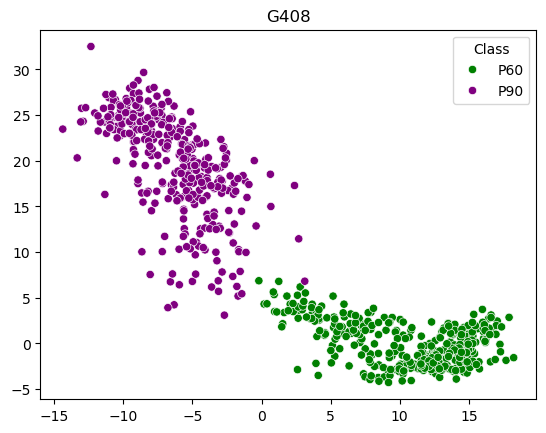

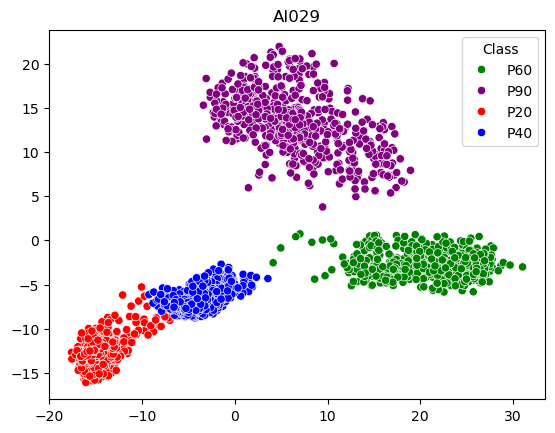

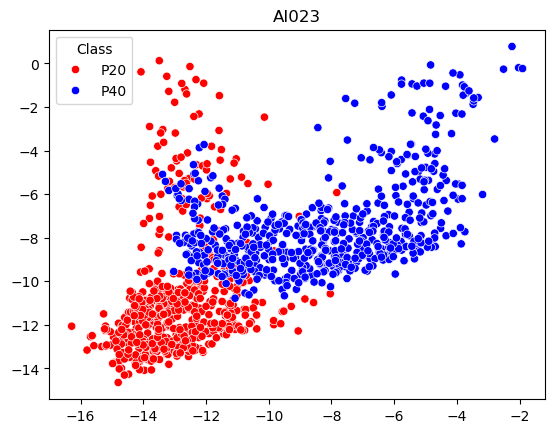

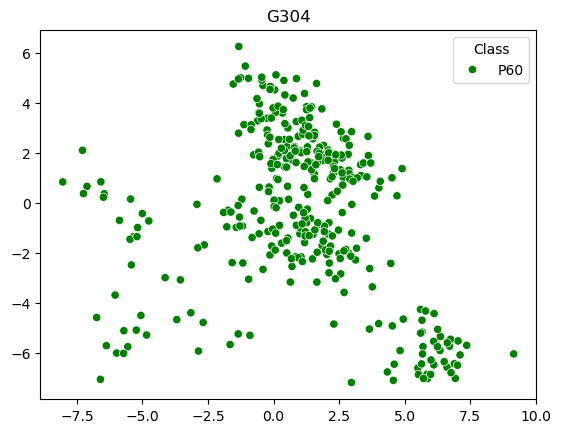

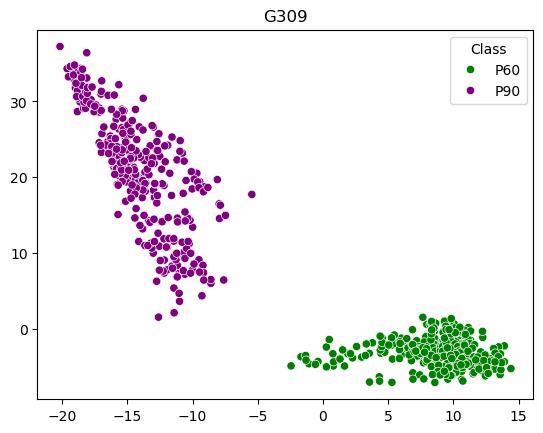

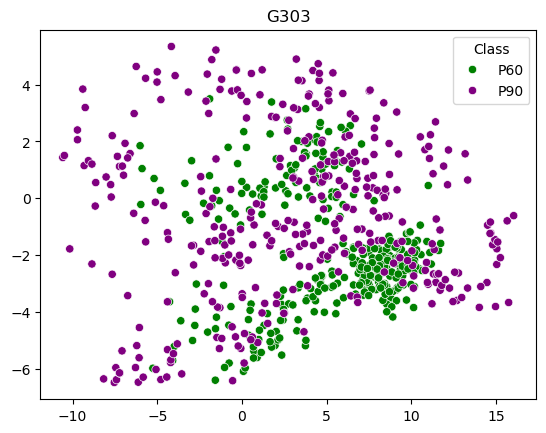

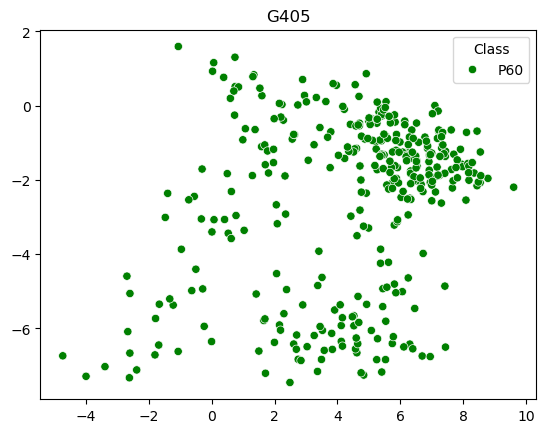

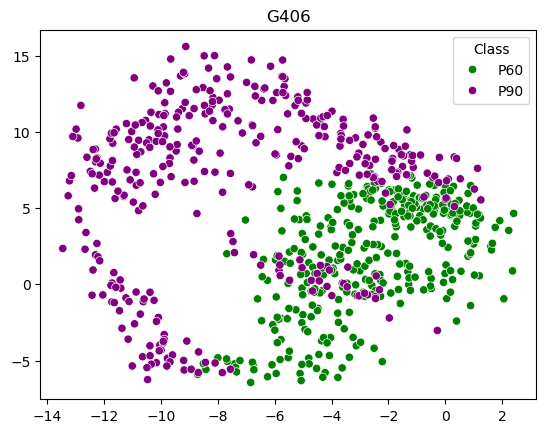

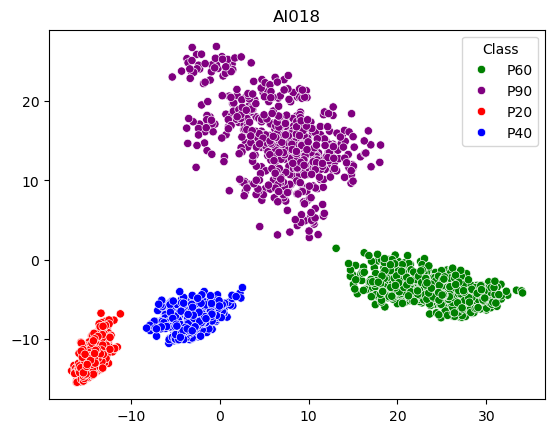

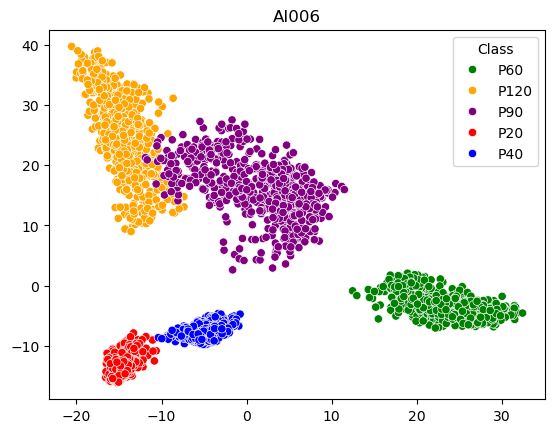

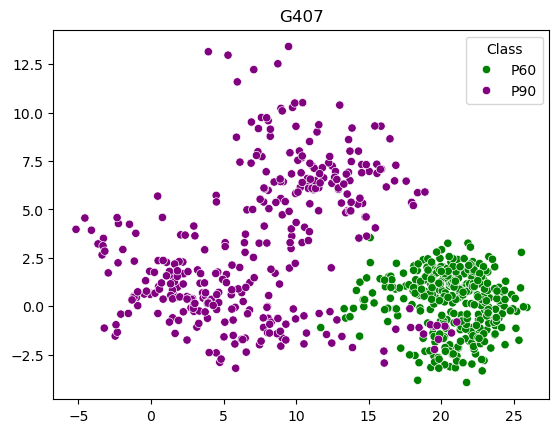

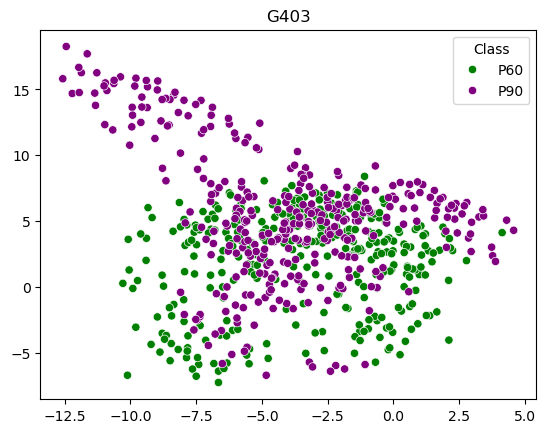

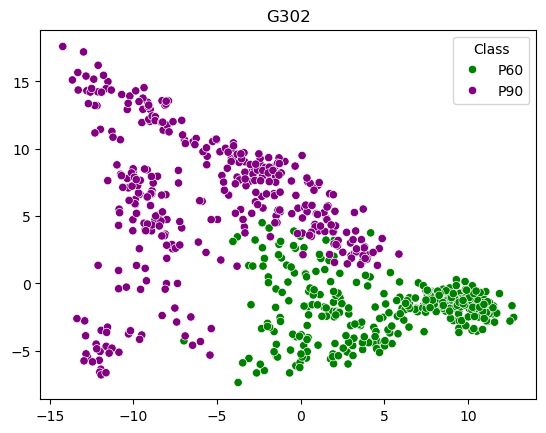

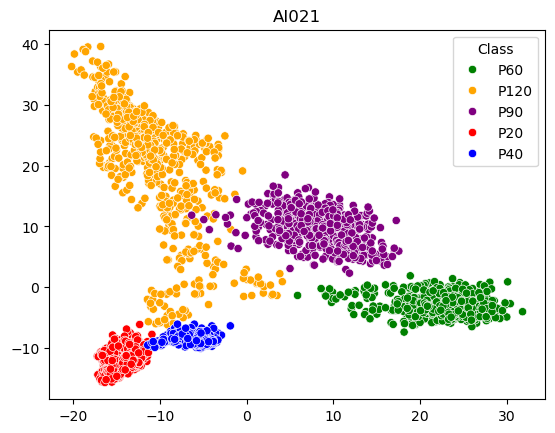

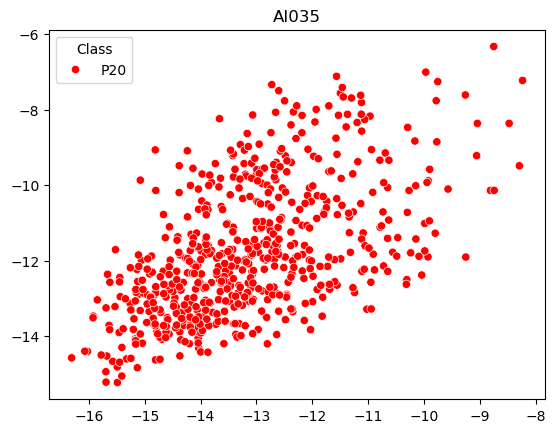

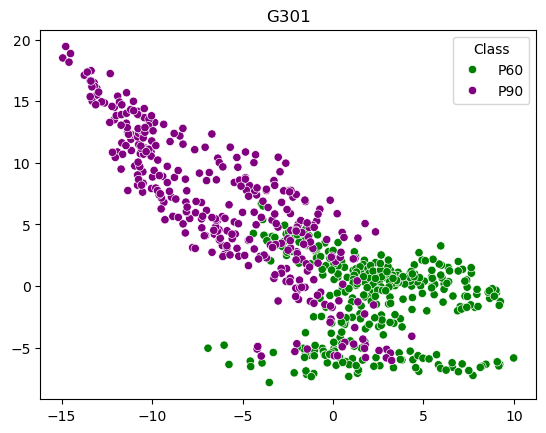

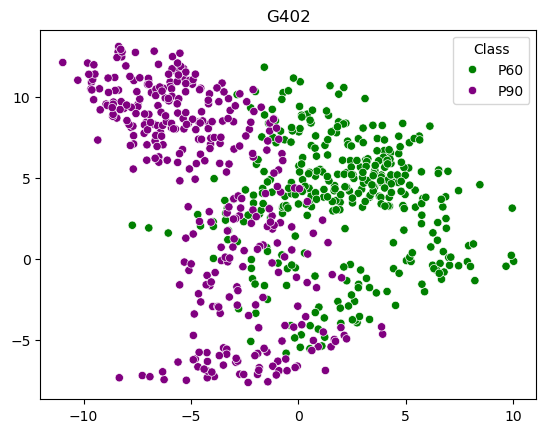

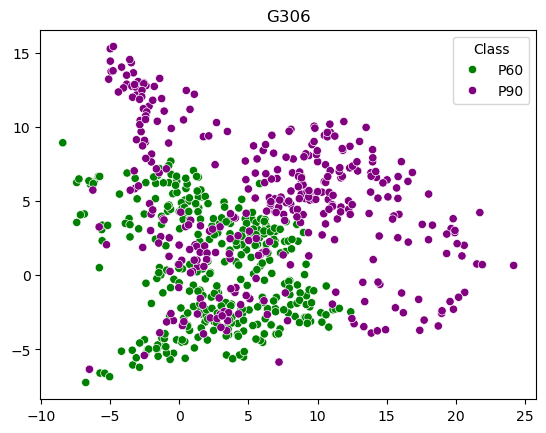

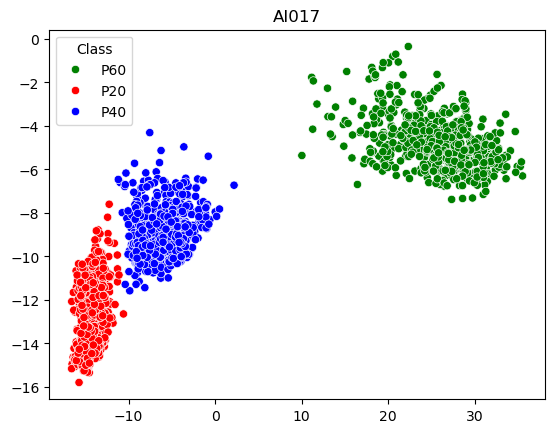

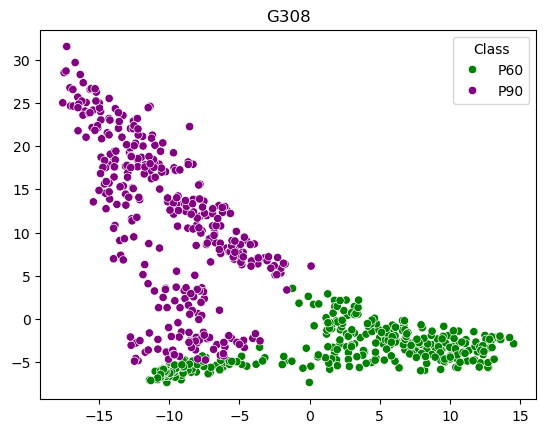

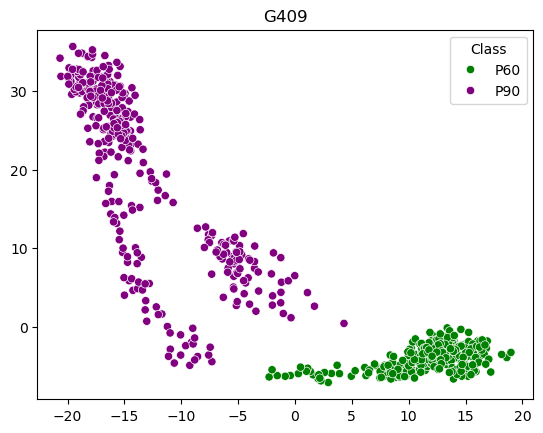

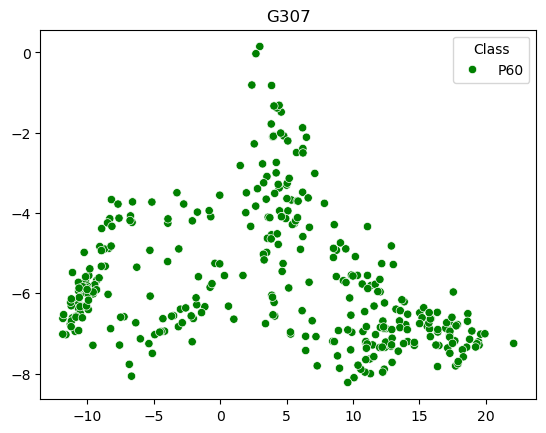

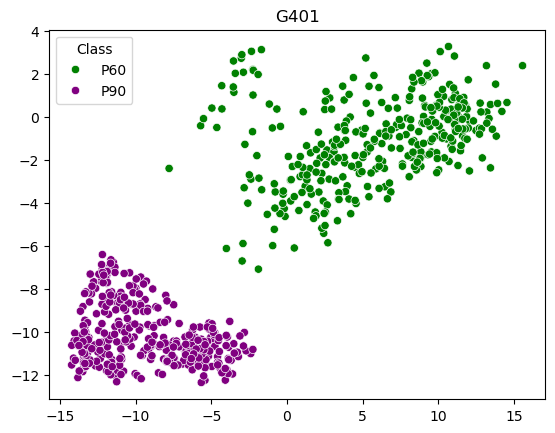

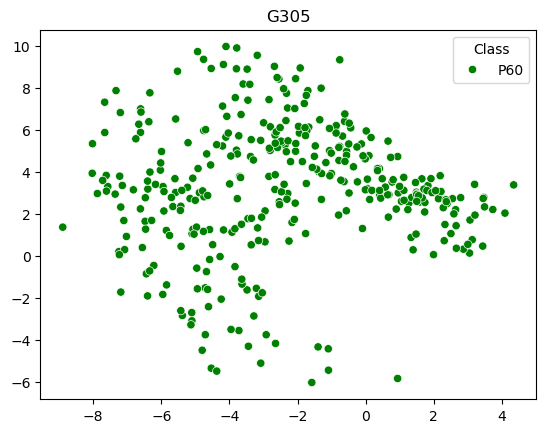

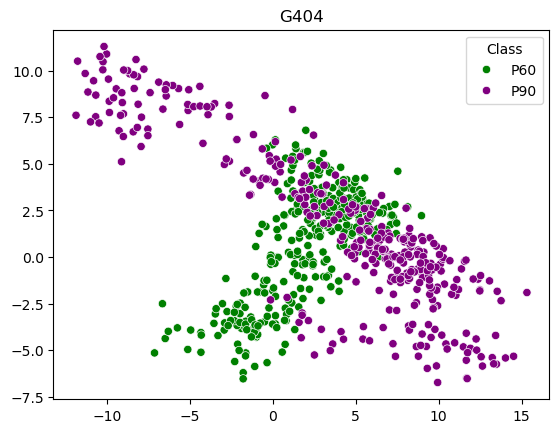

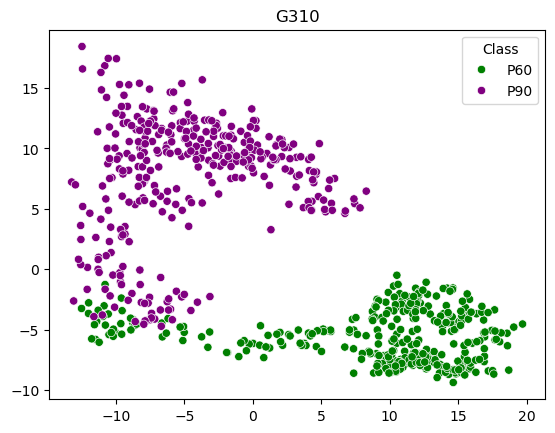

In [16]:
for ID in set(list(df['id'])):
    tmp_pca = output_pca[df['id'] == ID]
    tmp_df = df[df['id'] == ID]
    sns.scatterplot(x=tmp_pca[:, 0], y=tmp_pca[:, 1], hue=tmp_df.loc[:, 'gt'], palette=custom_palette)

    plt.title(ID)
    
    # Optionally, set legend
    plt.legend(title='Class', loc='best')
    
    # Show the plot
    plt.show()

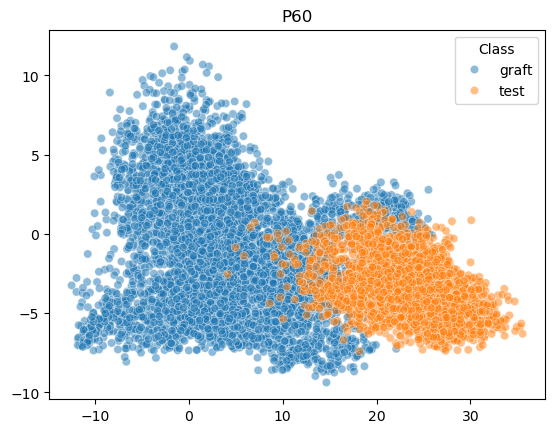

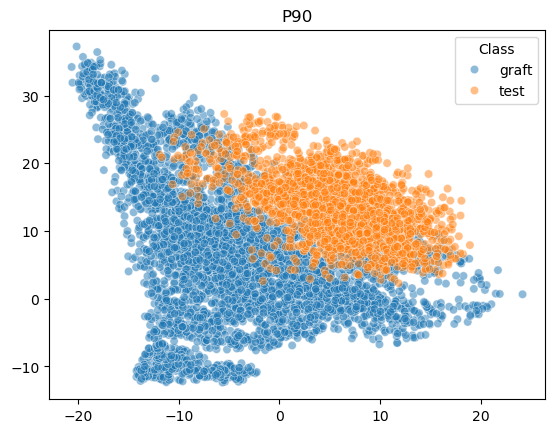

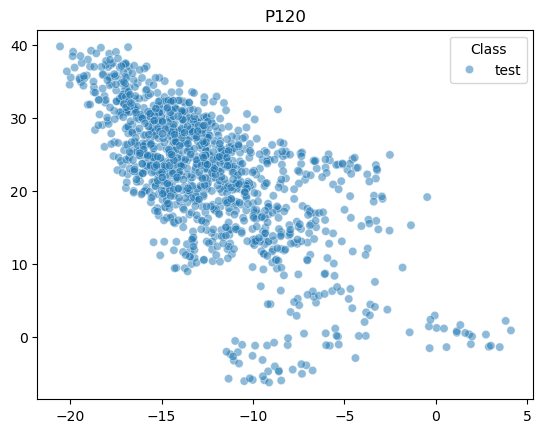

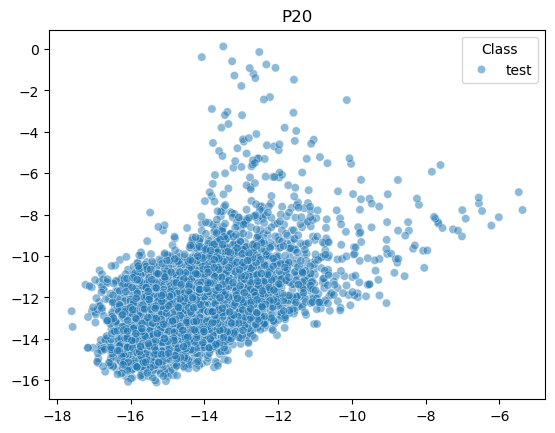

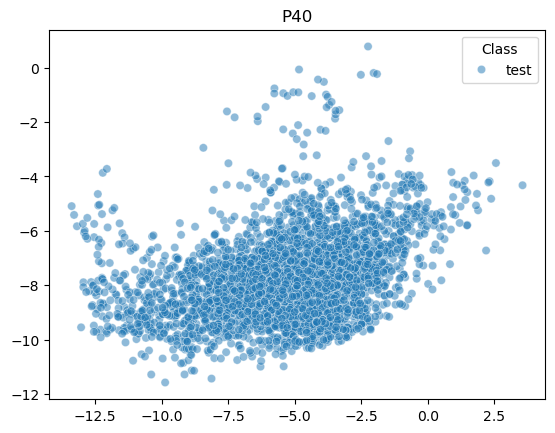

In [25]:
for gt in set(list(df['gt'])):
    tmp_pca = output_pca[df['gt'] == gt]
    tmp_df = df[df['gt'] == gt]
    sns.scatterplot(x=tmp_pca[:, 0], y=tmp_pca[:, 1], hue=tmp_df.loc[:, 'type'], alpha=0.5)

    plt.title(gt)
    
    # Optionally, set legend
    plt.legend(title='Class', loc='best')
    
    # Show the plot
    plt.show()

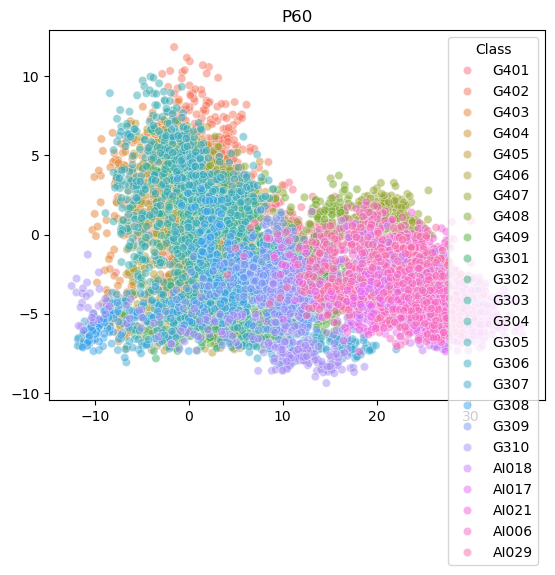

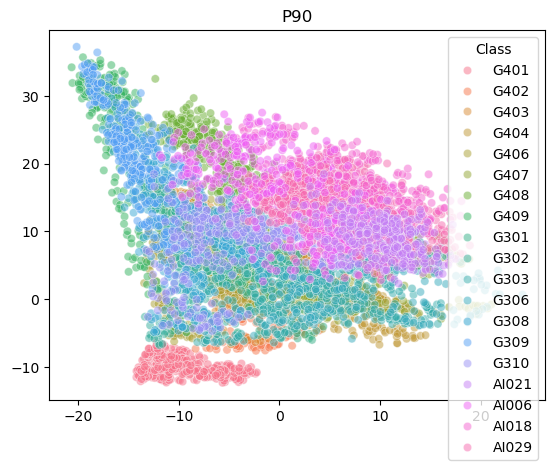

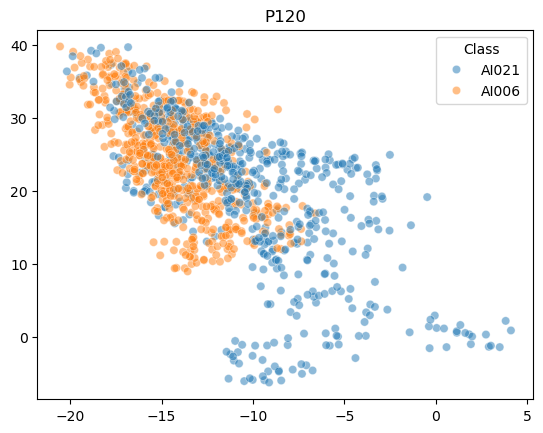

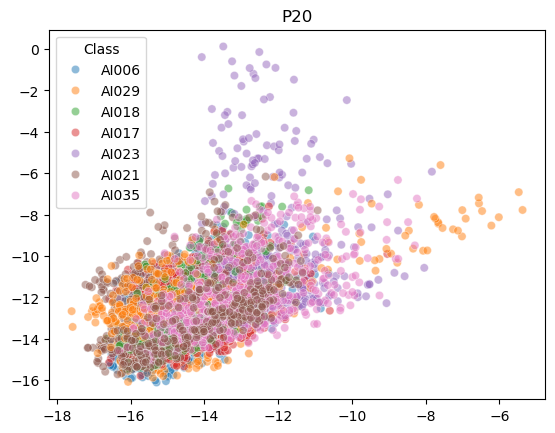

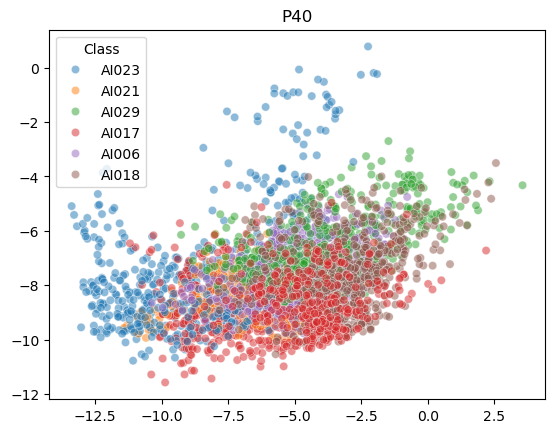

In [26]:
for gt in set(list(df['gt'])):
    tmp_pca = output_pca[df['gt'] == gt]
    tmp_df = df[df['gt'] == gt]
    sns.scatterplot(x=tmp_pca[:, 0], y=tmp_pca[:, 1], hue=tmp_df.loc[:, 'id'], alpha=0.5)

    plt.title(gt)
    
    # Optionally, set legend
    plt.legend(title='Class', loc='best')
    
    # Show the plot
    plt.show()

## Test data

In [27]:
tmp_pca = output_pca[df['type'] == 'test']
tmp_df = df[df['type'] == 'test']

<Axes: >

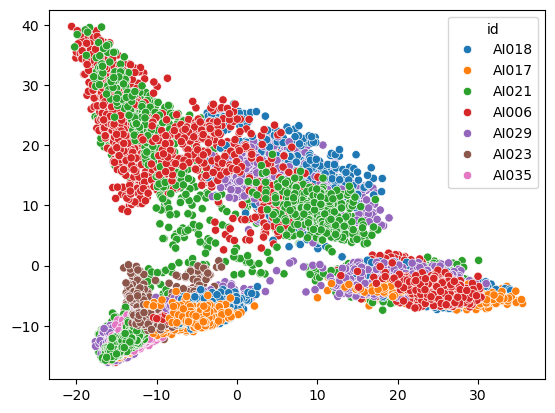

In [28]:
sns.scatterplot(x=tmp_pca[:, 0], y=tmp_pca[:, 1], hue=tmp_df.loc[:, 'id'])

<Axes: >

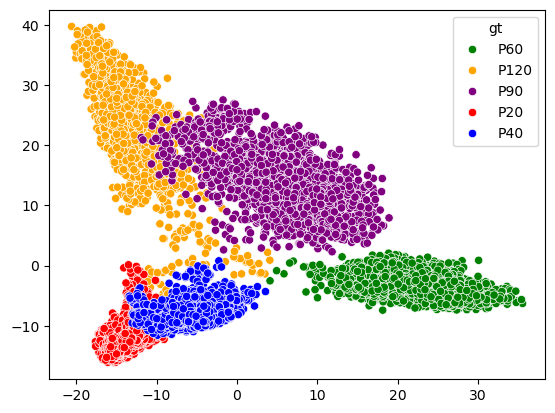

In [29]:
sns.scatterplot(x=tmp_pca[:, 0], y=tmp_pca[:, 1], hue=tmp_df.loc[:, 'gt'], palette=custom_palette)

## Graft data

In [30]:
tmp_pca = output_pca[df['type'] == 'graft']
tmp_df = df[df['type'] == 'graft']

<Axes: >

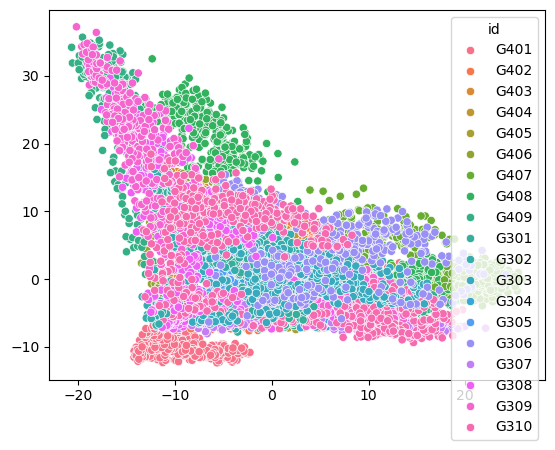

In [31]:
sns.scatterplot(x=tmp_pca[:, 0], y=tmp_pca[:, 1], hue=tmp_df.loc[:, 'id'])


<Axes: >

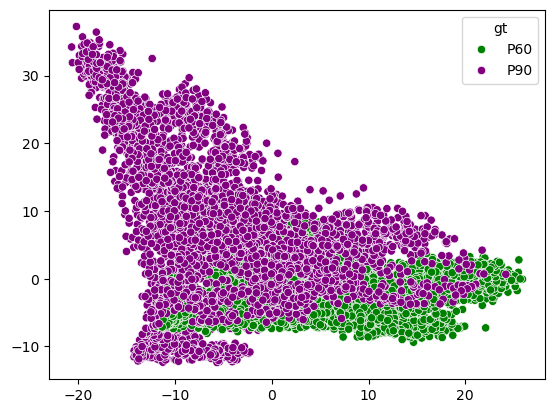

In [32]:
sns.scatterplot(x=tmp_pca[:, 0], y=tmp_pca[:, 1], hue=tmp_df.loc[:, 'gt'], palette=custom_palette)
